In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('eco2mix-national-cons-def.csv', sep=';')

/var/folders/0t/xgd_7rm13x72q88h20ctl0zm0000gn/T/ipykernel_92049/601800068.py:1: DtypeWarning: Columns (23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('eco2mix-national-cons-def.csv', sep=';')


In [11]:
df.shape

(485184, 37)

In [13]:
df.columns

Index(['Périmètre', 'Nature', 'Date', 'Heure', 'Date et Heure',
       'Consommation (MW)', 'Prévision J-1 (MW)', 'Prévision J (MW)',
       'Fioul (MW)', 'Charbon (MW)', 'Gaz (MW)', 'Nucléaire (MW)',
       'Eolien (MW)', 'Solaire (MW)', 'Hydraulique (MW)', 'Pompage (MW)',
       'Bioénergies (MW)', 'Ech. physiques (MW)', 'Taux de CO2 (g/kWh)',
       'Ech. comm. Angleterre (MW)', 'Ech. comm. Espagne (MW)',
       'Ech. comm. Italie (MW)', 'Ech. comm. Suisse (MW)',
       'Ech. comm. Allemagne-Belgique (MW)', 'Fioul - TAC (MW)',
       'Fioul - Cogénération (MW)', 'Fioul - Autres (MW)', 'Gaz - TAC (MW)',
       'Gaz - Cogénération (MW)', 'Gaz - CCG (MW)', 'Gaz - Autres (MW)',
       'Hydraulique - Fil de l'eau + éclusée (MW)', 'Hydraulique - Lacs (MW)',
       'Hydraulique - STEP turbinage (MW)', 'Bioénergies - Déchets (MW)',
       'Bioénergies - Biomasse (MW)', 'Bioénergies - Biogaz (MW)'],
      dtype='object')

In [16]:
df.columns.tolist()

['Périmètre',
 'Nature',
 'Date',
 'Heure',
 'Date et Heure',
 'Consommation (MW)',
 'Prévision J-1 (MW)',
 'Prévision J (MW)',
 'Fioul (MW)',
 'Charbon (MW)',
 'Gaz (MW)',
 'Nucléaire (MW)',
 'Eolien (MW)',
 'Solaire (MW)',
 'Hydraulique (MW)',
 'Pompage (MW)',
 'Bioénergies (MW)',
 'Ech. physiques (MW)',
 'Taux de CO2 (g/kWh)',
 'Ech. comm. Angleterre (MW)',
 'Ech. comm. Espagne (MW)',
 'Ech. comm. Italie (MW)',
 'Ech. comm. Suisse (MW)',
 'Ech. comm. Allemagne-Belgique (MW)',
 'Fioul - TAC (MW)',
 'Fioul - Cogénération (MW)',
 'Fioul - Autres (MW)',
 'Gaz - TAC (MW)',
 'Gaz - Cogénération (MW)',
 'Gaz - CCG (MW)',
 'Gaz - Autres (MW)',
 "Hydraulique - Fil de l'eau + éclusée (MW)",
 'Hydraulique - Lacs (MW)',
 'Hydraulique - STEP turbinage (MW)',
 'Bioénergies - Déchets (MW)',
 'Bioénergies - Biomasse (MW)',
 'Bioénergies - Biogaz (MW)']

In [17]:
df.isnull().sum()

Périmètre                                         0
Nature                                            0
Date                                              0
Heure                                             0
Date et Heure                                     0
Consommation (MW)                            242592
Prévision J-1 (MW)                                0
Prévision J (MW)                                  0
Fioul (MW)                                   242592
Charbon (MW)                                 242592
Gaz (MW)                                     242592
Nucléaire (MW)                               242592
Eolien (MW)                                  242592
Solaire (MW)                                 242592
Hydraulique (MW)                             242592
Pompage (MW)                                 242592
Bioénergies (MW)                             242592
Ech. physiques (MW)                          242592
Taux de CO2 (g/kWh)                          242592
Ech. comm. A

In [18]:
# Garder seulement les lignes avec des données réelles
df = df.dropna(subset=['Consommation (MW)'])

# Vérifier le résultat
print(df.shape)

(242592, 37)


In [19]:
df.isnull().sum()

Périmètre                                        0
Nature                                           0
Date                                             0
Heure                                            0
Date et Heure                                    0
Consommation (MW)                                0
Prévision J-1 (MW)                               0
Prévision J (MW)                                 0
Fioul (MW)                                       0
Charbon (MW)                                     0
Gaz (MW)                                         0
Nucléaire (MW)                                   0
Eolien (MW)                                      0
Solaire (MW)                                     0
Hydraulique (MW)                                 0
Pompage (MW)                                     0
Bioénergies (MW)                                 0
Ech. physiques (MW)                              0
Taux de CO2 (g/kWh)                              0
Ech. comm. Angleterre (MW)     

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].isnull().sum())
print(df.shape)

0
(242592, 40)


In [26]:
df['Mois'] = df['Date'].dt.month
df['Année'] = df['Date'].dt.year
df['Heure_num'] = df['Heure'].str[:2].astype(int)

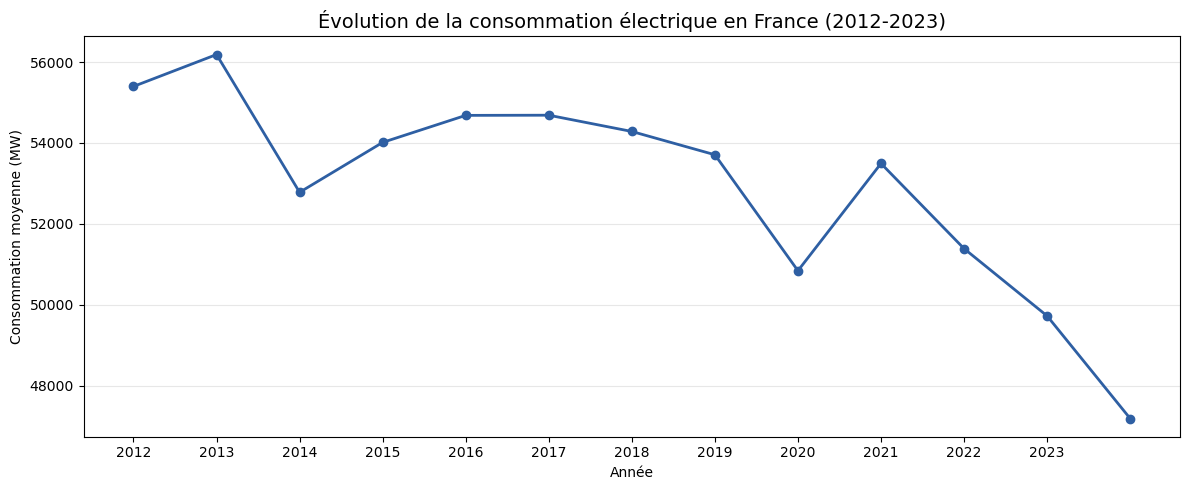

In [39]:
# Garder seulement les années complètes et fiables
df_filtre = df[df['Année'] <= 2024]

conso_par_annee = df_filtre.groupby('Année')['Consommation (MW)'].mean()

plt.figure(figsize=(12, 5))
plt.plot(conso_par_annee.index, conso_par_annee.values, 
         color='#2E5FA3', linewidth=2, marker='o')
plt.title('Évolution de la consommation électrique en France (2012-2023)', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Consommation moyenne (MW)')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique1_consommation.png')
plt.show()

In [34]:
df_reg = pd.read_csv('eco2mix-regional-cons-def.csv', sep=';', low_memory=False)
print(df_reg.shape)


(2645352, 32)


In [35]:
df_reg.columns.tolist()


['Code INSEE région',
 'Région',
 'Nature',
 'Date',
 'Heure',
 'Date - Heure',
 'Consommation (MW)',
 'Thermique (MW)',
 'Nucléaire (MW)',
 'Eolien (MW)',
 'Solaire (MW)',
 'Hydraulique (MW)',
 'Pompage (MW)',
 'Bioénergies (MW)',
 'Ech. physiques (MW)',
 'Stockage batterie',
 'Déstockage batterie',
 'Eolien terrestre',
 'Eolien offshore',
 'TCO Thermique (%)',
 'TCH Thermique (%)',
 'TCO Nucléaire (%)',
 'TCH Nucléaire (%)',
 'TCO Eolien (%)',
 'TCH Eolien (%)',
 'TCO Solaire (%)',
 'TCH Solaire (%)',
 'TCO Hydraulique (%)',
 'TCH Hydraulique (%)',
 'TCO Bioénergies (%)',
 'TCH Bioénergies (%)',
 'Column 30']

In [36]:
df_reg.isnull().sum()

Code INSEE région            0
Région                       0
Nature                       0
Date                         0
Heure                        0
Date - Heure                 0
Consommation (MW)           12
Thermique (MW)              12
Nucléaire (MW)          701287
Eolien (MW)                  0
Solaire (MW)                12
Hydraulique (MW)            12
Pompage (MW)            736327
Bioénergies (MW)            12
Ech. physiques (MW)         12
Stockage batterie      1683084
Déstockage batterie    1683084
Eolien terrestre       1683084
Eolien offshore        1683084
TCO Thermique (%)      1472257
TCH Thermique (%)      1472256
TCO Nucléaire (%)      1560097
TCH Nucléaire (%)      1962096
TCO Eolien (%)         1472257
TCH Eolien (%)         1472256
TCO Solaire (%)        1472257
TCH Solaire (%)        1472256
TCO Hydraulique (%)    1472257
TCH Hydraulique (%)    1472256
TCO Bioénergies (%)    1472257
TCH Bioénergies (%)    1472256
Column 30              2645352
dtype: i

In [37]:
# Nettoyer
df_reg = df_reg.dropna(subset=['Consommation (MW)'])
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg['Année'] = df_reg['Date'].dt.year
df_reg = df_reg[df_reg['Année'] <= 2023]

# Vérifier
print(df_reg.shape)
print(df_reg['Région'].unique())

(2311260, 33)
['Hauts-de-France' 'Auvergne-Rhône-Alpes' 'Nouvelle-Aquitaine'
 'Pays de la Loire' "Provence-Alpes-Côte d'Azur" 'Bretagne' 'Grand Est'
 'Occitanie' 'Normandie' 'Île-de-France' 'Bourgogne-Franche-Comté'
 'Centre-Val de Loire']


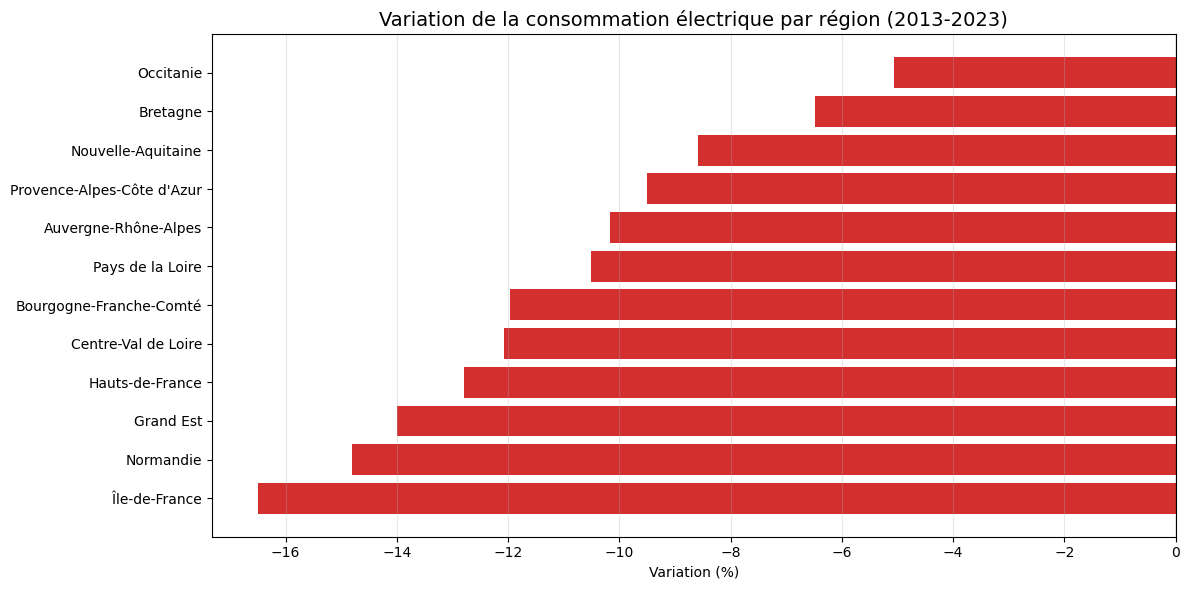

In [40]:
# Consommation moyenne par région et par année
conso_region = df_reg.groupby(['Région', 'Année'])['Consommation (MW)'].mean().reset_index()

# Garder seulement 2013 et 2023 pour comparer le début et la fin
conso_2013 = conso_region[conso_region['Année'] == 2013].set_index('Région')['Consommation (MW)']
conso_2023 = conso_region[conso_region['Année'] == 2023].set_index('Région')['Consommation (MW)']

# Calculer la variation en %
variation = ((conso_2023 - conso_2013) / conso_2013 * 100).sort_values()

# Graphique
plt.figure(figsize=(12, 6))
colors = ['#d32f2f' if x < 0 else '#2E5FA3' for x in variation.values]
bars = plt.barh(variation.index, variation.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Variation de la consommation électrique par région (2013-2023)', fontsize=14)
plt.xlabel('Variation (%)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique1_regions.png')
plt.show()

In [41]:
print("Variación por región (2013-2023):")
print(variation.round(1))
print(f"\nRegión con mayor bajada: {variation.idxmin()} ({variation.min():.1f}%)")
print(f"Región con menor bajada: {variation.idxmax()} ({variation.max():.1f}%)")


Variación por región (2013-2023):
Région
Île-de-France                -16.5
Normandie                    -14.8
Grand Est                    -14.0
Hauts-de-France              -12.8
Centre-Val de Loire          -12.1
Bourgogne-Franche-Comté      -12.0
Pays de la Loire             -10.5
Auvergne-Rhône-Alpes         -10.2
Provence-Alpes-Côte d'Azur    -9.5
Nouvelle-Aquitaine            -8.6
Bretagne                      -6.5
Occitanie                     -5.1
Name: Consommation (MW), dtype: float64

Región con mayor bajada: Île-de-France (-16.5%)
Región con menor bajada: Occitanie (-5.1%)


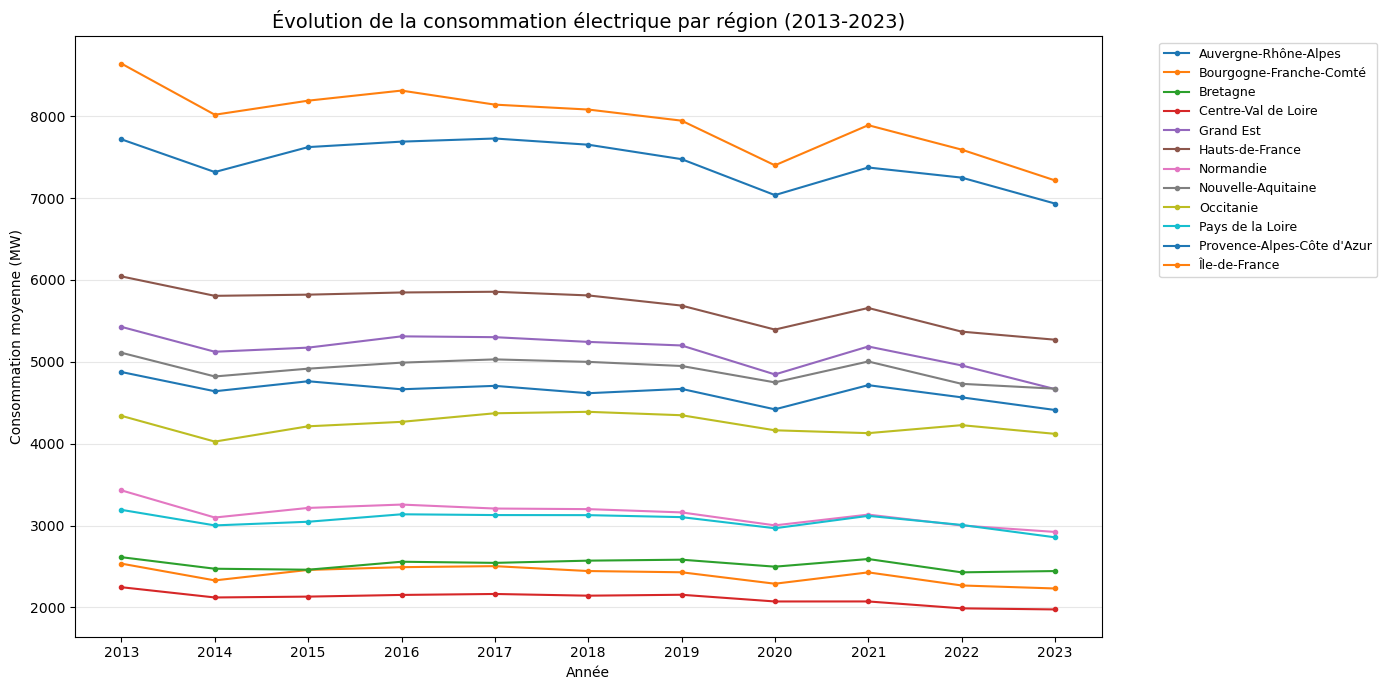

In [42]:
# Evolución por región y por año
conso_pivot = conso_region.pivot(index='Année', columns='Région', values='Consommation (MW)')

plt.figure(figsize=(14, 7))
for region in conso_pivot.columns:
    plt.plot(conso_pivot.index, conso_pivot[region], linewidth=1.5, marker='o', markersize=3, label=region)

plt.title('Évolution de la consommation électrique par région (2013-2023)', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Consommation moyenne (MW)')
plt.xticks(range(2013, 2024))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique1b_regions_annees.png')
plt.show()

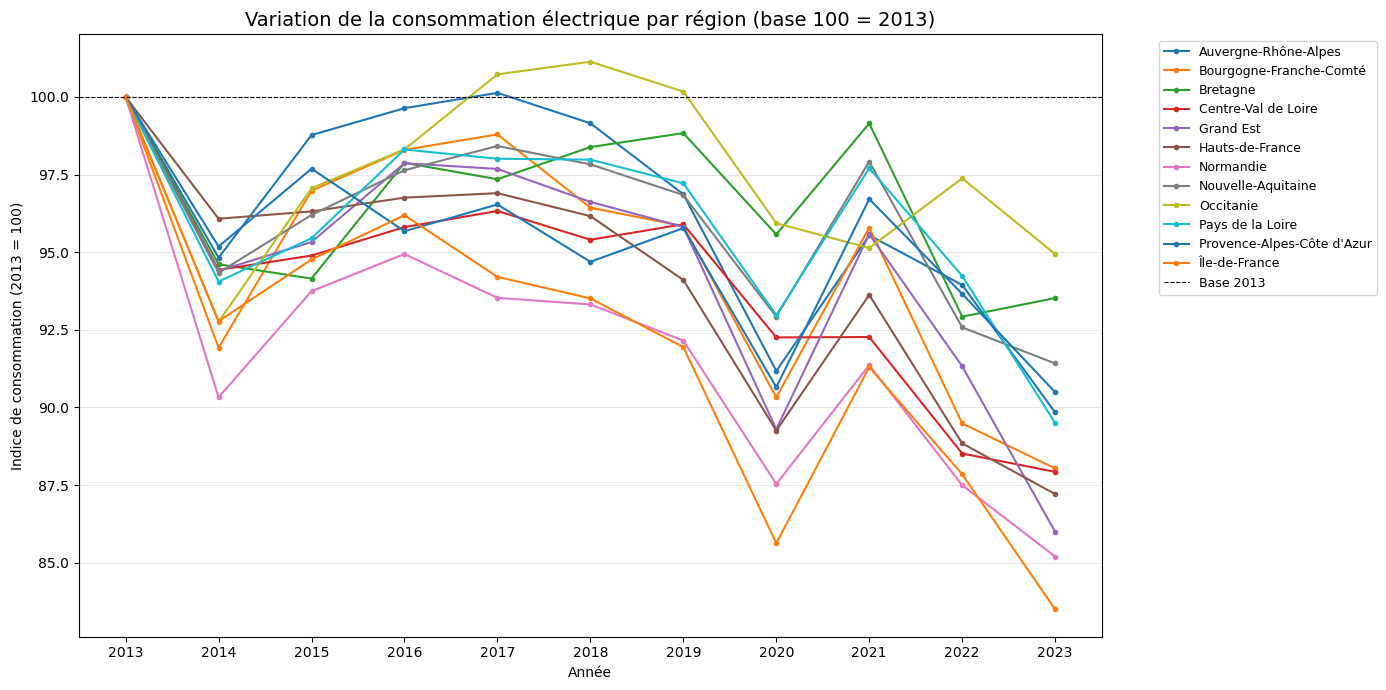

In [43]:
# Normaliser par rapport à 2013 (2013 = 100%)
conso_base = conso_pivot.div(conso_pivot.loc[2013]) * 100

plt.figure(figsize=(14, 7))
for region in conso_base.columns:
    plt.plot(conso_base.index, conso_base[region], linewidth=1.5, marker='o', markersize=3, label=region)

plt.axhline(y=100, color='black', linewidth=0.8, linestyle='--', label='Base 2013')
plt.title('Variation de la consommation électrique par région (base 100 = 2013)', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Indice de consommation (2013 = 100)')
plt.xticks(range(2013, 2024))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique1c_variation_regions.png')
plt.show()

In [44]:
# Valeurs exactes par région pour chaque année
print(conso_base.round(1).to_string())

Région  Auvergne-Rhône-Alpes  Bourgogne-Franche-Comté  Bretagne  Centre-Val de Loire  Grand Est  Hauts-de-France  Normandie  Nouvelle-Aquitaine  Occitanie  Pays de la Loire  Provence-Alpes-Côte d'Azur  Île-de-France
Année                                                                                                                                                                                                                  
2013                   100.0                    100.0     100.0                100.0      100.0            100.0      100.0               100.0      100.0             100.0                       100.0          100.0
2014                    94.8                     91.9      94.6                 94.4       94.4             96.1       90.3                94.3       92.8              94.1                        95.2           92.8
2015                    98.8                     97.0      94.1                 94.9       95.3             96.3       93.7             

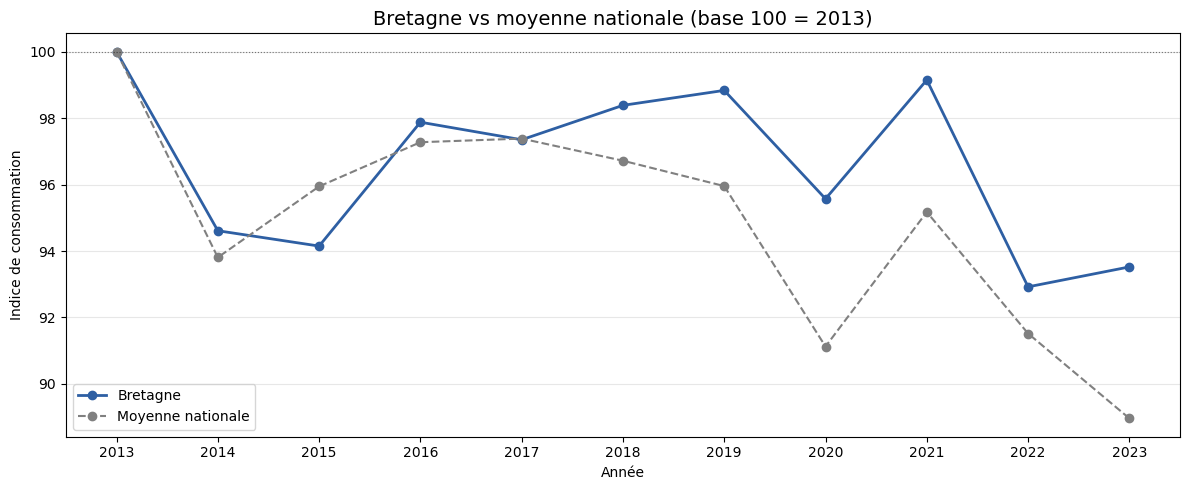

In [45]:
# Bretagne vs moyenne nationale
moyenne_nationale = conso_base.mean(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(conso_base.index, conso_base['Bretagne'], 
         color='#2E5FA3', linewidth=2, marker='o', label='Bretagne')
plt.plot(conso_base.index, moyenne_nationale, 
         color='gray', linewidth=1.5, linestyle='--', marker='o', label='Moyenne nationale')
plt.axhline(y=100, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
plt.title('Bretagne vs moyenne nationale (base 100 = 2013)', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Indice de consommation')
plt.xticks(range(2013, 2024))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique1d_bretagne.png')
plt.show()

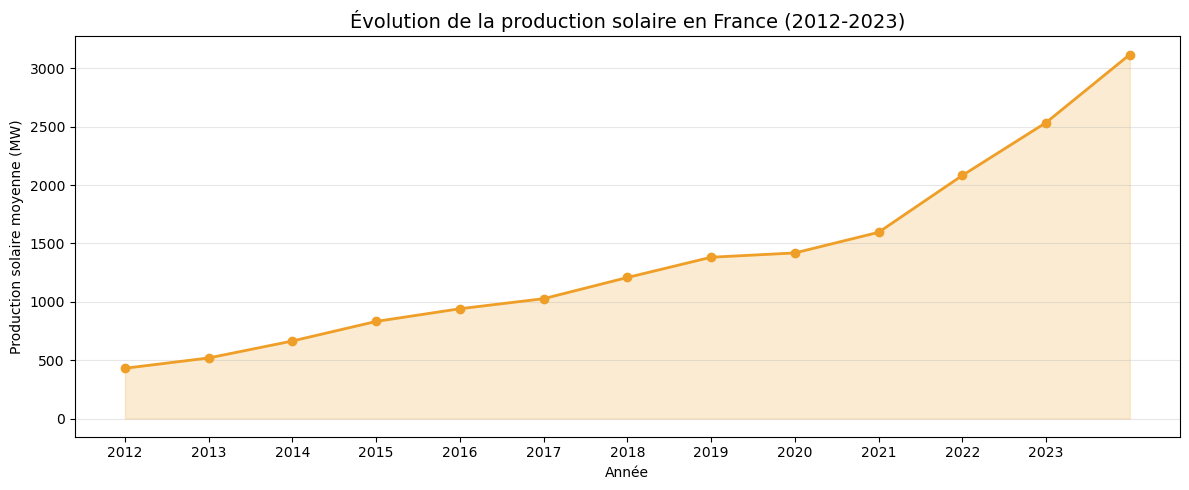

In [46]:
solaire_par_annee = df_filtre.groupby('Année')['Solaire (MW)'].mean()

plt.figure(figsize=(12, 5))
plt.plot(solaire_par_annee.index, solaire_par_annee.values, 
         color='#EF9F27', linewidth=2, marker='o')
plt.fill_between(solaire_par_annee.index, solaire_par_annee.values, 
                 alpha=0.2, color='#EF9F27')
plt.title('Évolution de la production solaire en France (2012-2023)', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Production solaire moyenne (MW)')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique2_solaire.png')
plt.show()


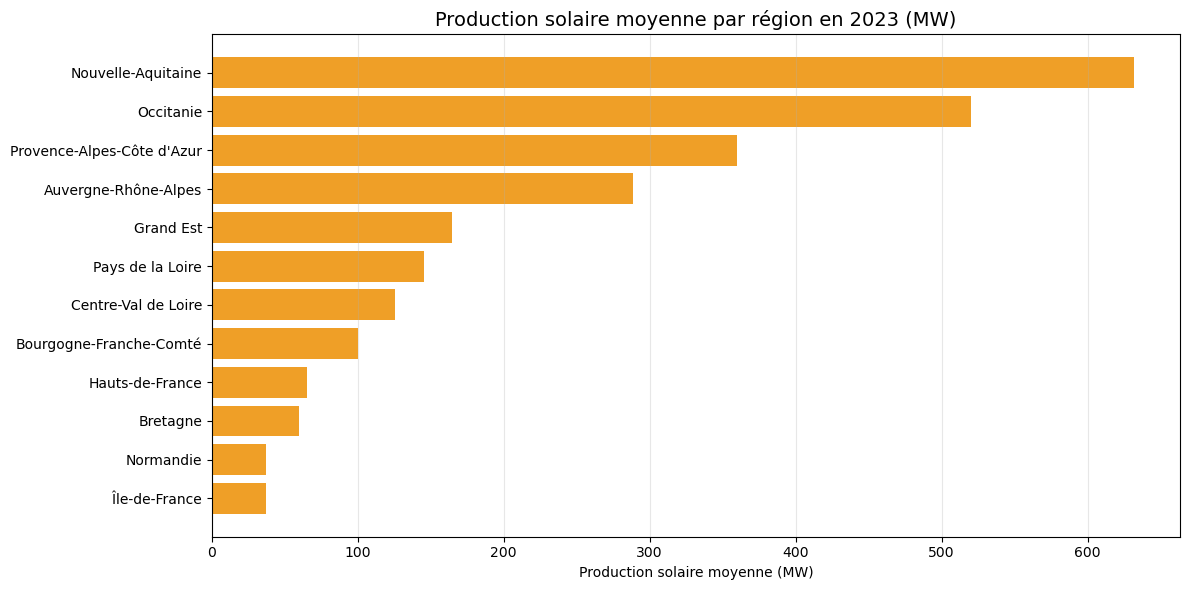

In [47]:
# Production solaire moyenne par région en 2023
solaire_2023 = df_reg[df_reg['Année'] == 2023].groupby('Région')['Solaire (MW)'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(solaire_2023.index, solaire_2023.values, color='#EF9F27')
plt.title('Production solaire moyenne par région en 2023 (MW)', fontsize=14)
plt.xlabel('Production solaire moyenne (MW)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique2b_solaire_regions.png')
plt.show()


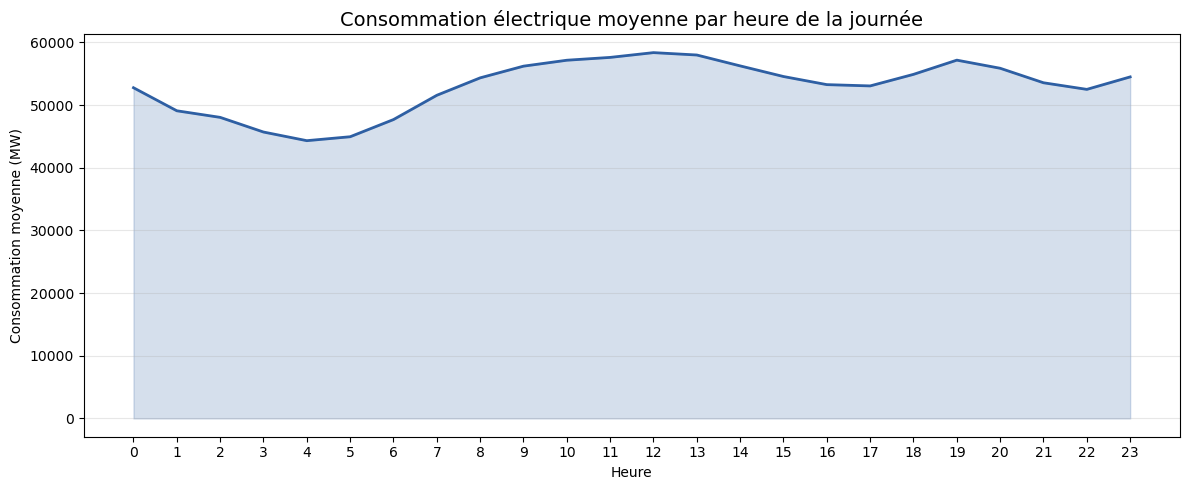

Pic maximum : 12h — 58373 MW
Creux minimum : 4h — 44323 MW
Différence : 14050 MW


In [48]:
# Question 3 : À quelle heure la consommation est-elle maximale ?
conso_par_heure = df.groupby('Heure_num')['Consommation (MW)'].mean()

plt.figure(figsize=(12, 5))
plt.plot(conso_par_heure.index, conso_par_heure.values, 
         color='#2E5FA3', linewidth=2)
plt.fill_between(conso_par_heure.index, conso_par_heure.values, 
                 alpha=0.2, color='#2E5FA3')
plt.title('Consommation électrique moyenne par heure de la journée', fontsize=14)
plt.xlabel('Heure')
plt.ylabel('Consommation moyenne (MW)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique3_heures.png')
plt.show()

# Chiffres exacts
heure_max = conso_par_heure.idxmax()
valeur_max = conso_par_heure.max()
heure_min = conso_par_heure.idxmin()
valeur_min = conso_par_heure.min()

print(f"Pic maximum : {heure_max}h — {valeur_max:.0f} MW")
print(f"Creux minimum : {heure_min}h — {valeur_min:.0f} MW")
print(f"Différence : {valeur_max - valeur_min:.0f} MW")

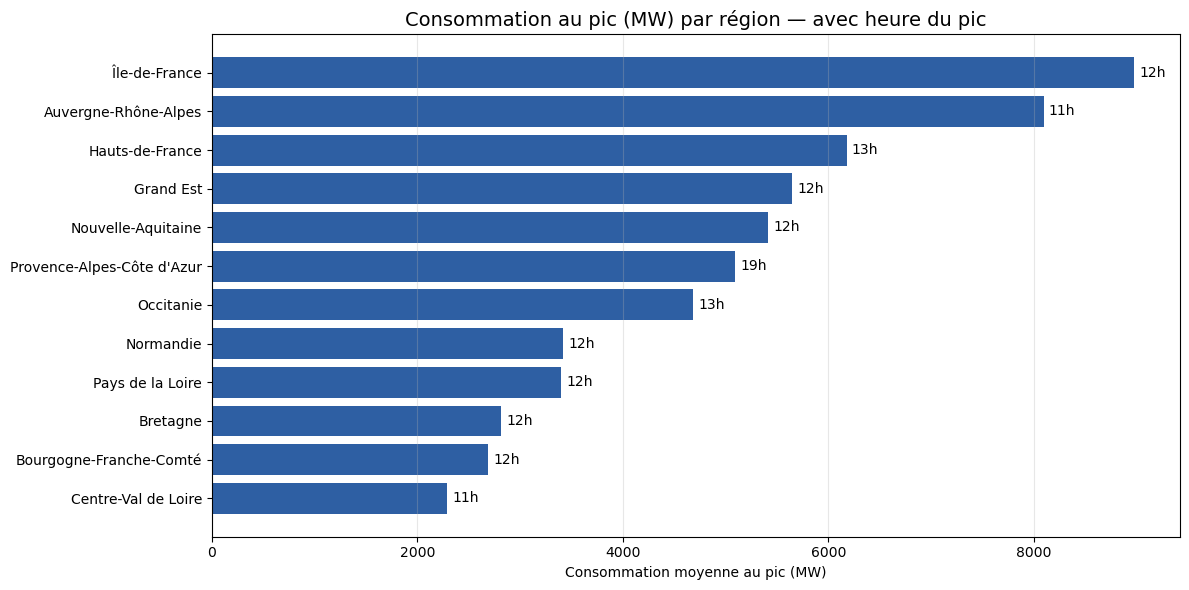

                         Région  Heure_num  Consommation (MW)
83          Centre-Val de Loire         11        2288.826861
36      Bourgogne-Franche-Comté         12        2689.672517
60                     Bretagne         12        2818.963654
228            Pays de la Loire         12        3402.084018
156                   Normandie         12        3418.455937
205                   Occitanie         13        4684.761731
259  Provence-Alpes-Côte d'Azur         19        5090.433035
180          Nouvelle-Aquitaine         12        5415.770102
108                   Grand Est         12        5649.169654
133             Hauts-de-France         13        6178.146751
11         Auvergne-Rhône-Alpes         11        8092.710854
276               Île-de-France         12        8972.157207


In [49]:
# Consommation moyenne par région et par heure
df_reg['Heure_num'] = df_reg['Heure'].str[:2].astype(int)
conso_region_heure = df_reg.groupby(['Région', 'Heure_num'])['Consommation (MW)'].mean().reset_index()

# Trouver l'heure de pic par région
pic_par_region = conso_region_heure.loc[conso_region_heure.groupby('Région')['Consommation (MW)'].idxmax()]
pic_par_region = pic_par_region.sort_values('Consommation (MW)', ascending=True)

# Graphique
plt.figure(figsize=(12, 6))
plt.barh(pic_par_region['Région'], pic_par_region['Consommation (MW)'], color='#2E5FA3')
for i, (val, heure) in enumerate(zip(pic_par_region['Consommation (MW)'], pic_par_region['Heure_num'])):
    plt.text(val + 50, i, f'{heure}h', va='center', fontsize=10)
plt.title('Consommation au pic (MW) par région — avec heure du pic', fontsize=14)
plt.xlabel('Consommation moyenne au pic (MW)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique3b_pic_regions.png')
plt.show()

# Chiffres exacts
print(pic_par_region[['Région', 'Heure_num', 'Consommation (MW)']].to_string())

In [50]:
df_prix = pd.read_csv('Option_Base.csv', sep=';')
print(df_prix.shape)
print(df_prix.columns.tolist())
df_prix.head(10)

(110, 7)
['DATE_DEBUT', 'DATE_FIN', 'P_SOUSCRITE', 'PART_FIXE_HT', 'PART_FIXE_TTC', 'PART_VARIABLE_HT', 'PART_VARIABLE_TTC']


,DATE_DEBUT,DATE_FIN,P_SOUSCRITE,PART_FIXE_HT,PART_FIXE_TTC,PART_VARIABLE_HT,PART_VARIABLE_TTC
0,23/07/2012,31/07/2013,3,"55,56","69,37","0,0822","0,1256"
1,23/07/2012,31/07/2013,6,"65,64","82,98","0,0828","0,1263"
2,23/07/2012,31/07/2013,9,"76,08","96,97","0,0848","0,1287"
3,23/07/2012,31/07/2013,12,"118,08","153,7","0,0848","0,1287"
4,23/07/2012,31/07/2013,15,"135,72","177,66","0,0848","0,1287"
5,01/08/2013,31/10/2014,3,"38,88","51,7","0,0883","0,1329"
6,01/08/2013,31/10/2014,6,"66,72","84,05","0,0883","0,1329"
7,01/08/2013,31/10/2014,9,"89,76","111,33","0,0883","0,1329"
8,01/08/2013,31/10/2014,12,135,"171,49","0,0883","0,1329"
9,01/08/2013,31/10/2014,15,"153,84","196,7","0,0883","0,1329"


In [51]:
# Explorer les données
print(df_prix.shape)
print(df_prix.isnull().sum())
print(df_prix.duplicated().sum())
df_prix['P_SOUSCRITE'].unique()

(110, 7)
DATE_DEBUT           0
DATE_FIN             5
P_SOUSCRITE          0
PART_FIXE_HT         0
PART_FIXE_TTC        0
PART_VARIABLE_HT     0
PART_VARIABLE_TTC    0
dtype: int64
0


array([ 3,  6,  9, 12, 15])

In [52]:
# Vérifier les valeurs de puissance disponibles
print("Puissances disponibles :", df_prix['P_SOUSCRITE'].unique())

# Vérifier le format des valeurs numériques
print("\nExemple PART_VARIABLE_TTC :", df_prix['PART_VARIABLE_TTC'].head())
print("Type :", df_prix['PART_VARIABLE_TTC'].dtype)

Puissances disponibles : [ 3  6  9 12 15]

Exemple PART_VARIABLE_TTC : 0    0,1256
1    0,1263
2    0,1287
3    0,1287
4    0,1287
Name: PART_VARIABLE_TTC, dtype: object
Type : object


In [53]:
# Convertir les virgules en points pour toutes les colonnes numériques
for col in ['PART_FIXE_HT', 'PART_FIXE_TTC', 'PART_VARIABLE_HT', 'PART_VARIABLE_TTC']:
    df_prix[col] = df_prix[col].astype(str).str.replace(',', '.').astype(float)

# Convertir les dates
df_prix['DATE_DEBUT'] = pd.to_datetime(df_prix['DATE_DEBUT'], format='%d/%m/%Y')
df_prix['DATE_FIN'] = pd.to_datetime(df_prix['DATE_FIN'], format='%d/%m/%Y', errors='coerce')

# Ajouter colonne Année
df_prix['Année'] = df_prix['DATE_DEBUT'].dt.year

# Vérifier
print("Types après nettoyage :")
print(df_prix.dtypes)
print("\nAperçu :")
print(df_prix[['DATE_DEBUT', 'P_SOUSCRITE', 'PART_VARIABLE_TTC']].head(10))

Types après nettoyage :
DATE_DEBUT           datetime64[ns]
DATE_FIN             datetime64[ns]
P_SOUSCRITE                   int64
PART_FIXE_HT                float64
PART_FIXE_TTC               float64
PART_VARIABLE_HT            float64
PART_VARIABLE_TTC           float64
Année                         int32
dtype: object

Aperçu :
  DATE_DEBUT  P_SOUSCRITE  PART_VARIABLE_TTC
0 2012-07-23            3             0.1256
1 2012-07-23            6             0.1263
2 2012-07-23            9             0.1287
3 2012-07-23           12             0.1287
4 2012-07-23           15             0.1287
5 2013-08-01            3             0.1329
6 2013-08-01            6             0.1329
7 2013-08-01            9             0.1329
8 2013-08-01           12             0.1329
9 2013-08-01           15             0.1329


In [55]:
# Convertir consommation MW -> kWh (mesures toutes les 30 min)
df['Consommation (kWh)'] = df['Consommation (MW)'] * 1000 * 0.5

# Consommation annuelle totale en kWh
conso_kwh_annee = df[df['Année'] <= 2023].groupby('Année')['Consommation (kWh)'].sum()

# Prix moyen par année (6 kVA)
prix_par_annee = df_prix6.groupby('Année')['PART_VARIABLE_TTC'].mean()

# Coût total annuel = consommation kWh × prix €/kWh
cout_annuel = conso_kwh_annee * prix_par_annee

# Vérifier
print("Consommation annuelle (kWh) :")
print(conso_kwh_annee.head())
print("\nPrix moyen €/kWh :")
print(prix_par_annee.head())
print("\nCoût annuel estimé (€) :")
print(cout_annuel.head())

Consommation annuelle (kWh) :
Année
2012    4.866069e+11
2013    4.921852e+11
2014    4.623484e+11
2015    4.731528e+11
2016    4.803204e+11
Name: Consommation (kWh), dtype: float64

Prix moyen €/kWh :
Année
2012    0.1263
2013    0.1329
2014    0.1401
2015    0.1437
2016    0.1503
Name: PART_VARIABLE_TTC, dtype: float64

Coût annuel estimé (€) :
Année
2012    6.145845e+10
2013    6.541142e+10
2014    6.477501e+10
2015    6.799206e+10
2016    7.219216e+10
dtype: float64


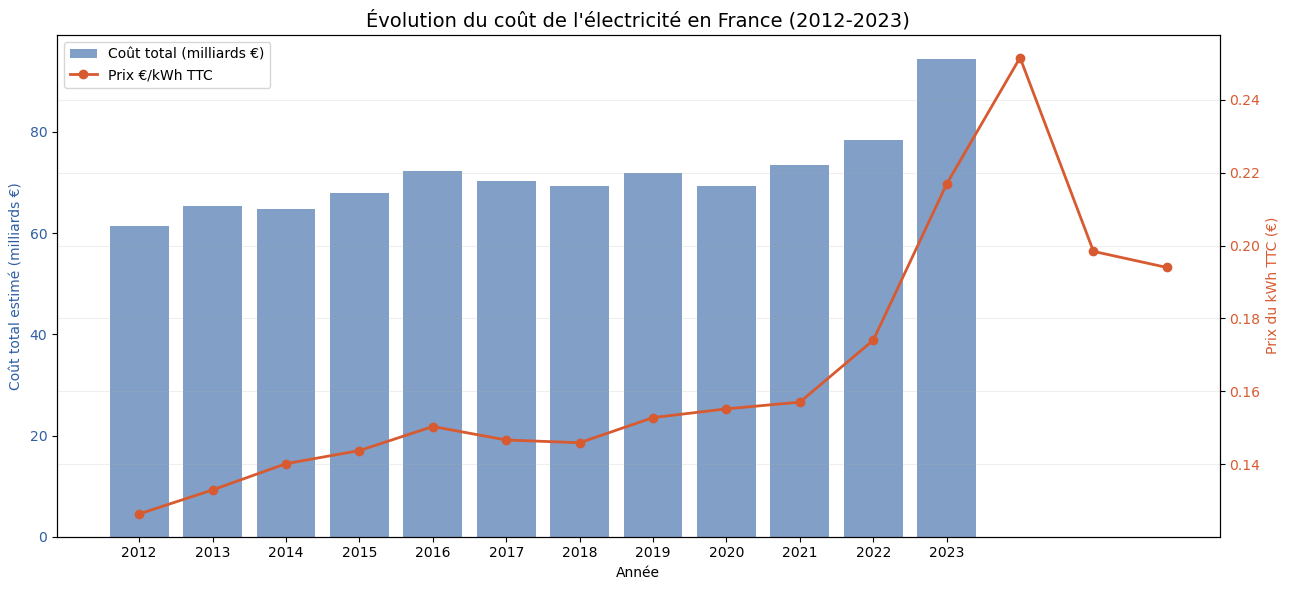


Coût total annuel estimé (milliards €) :
Année
2012    61.5
2013    65.4
2014    64.8
2015    68.0
2016    72.2
2017    70.2
2018    69.4
2019    71.9
2020    69.3
2021    73.6
2022    78.3
2023    94.5
2024     NaN
2025     NaN
2026     NaN
dtype: float64

Prix du kWh TTC par année :
Année
2012    0.1263
2013    0.1329
2014    0.1401
2015    0.1437
2016    0.1503
2017    0.1466
2018    0.1458
2019    0.1528
2020    0.1552
2021    0.1570
2022    0.1740
2023    0.2169
2024    0.2516
2025    0.1984
2026    0.1940
Name: PART_VARIABLE_TTC, dtype: float64


In [56]:
# Convertir en milliards pour lisibilité
cout_milliards = cout_annuel / 1e9
conso_twh = conso_kwh_annee / 1e9  # kWh -> TWh

fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche — coût total
ax1.bar(cout_milliards.index, cout_milliards.values,
        color='#2E5FA3', alpha=0.6, label='Coût total (milliards €)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Coût total estimé (milliards €)', color='#2E5FA3')
ax1.tick_params(axis='y', labelcolor='#2E5FA3')

# Axe droit — prix au kWh
ax2 = ax1.twinx()
ax2.plot(prix_par_annee.index, prix_par_annee.values,
         color='#D85A30', linewidth=2, marker='o', label='Prix €/kWh TTC')
ax2.set_ylabel('Prix du kWh TTC (€)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title("Évolution du coût de l'électricité en France (2012-2023)", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('graphique4_cout_electricite.png')
plt.show()

# Chiffres exacts
print("\nCoût total annuel estimé (milliards €) :")
print(cout_milliards.round(1))
print("\nPrix du kWh TTC par année :")
print(prix_par_annee.round(4))

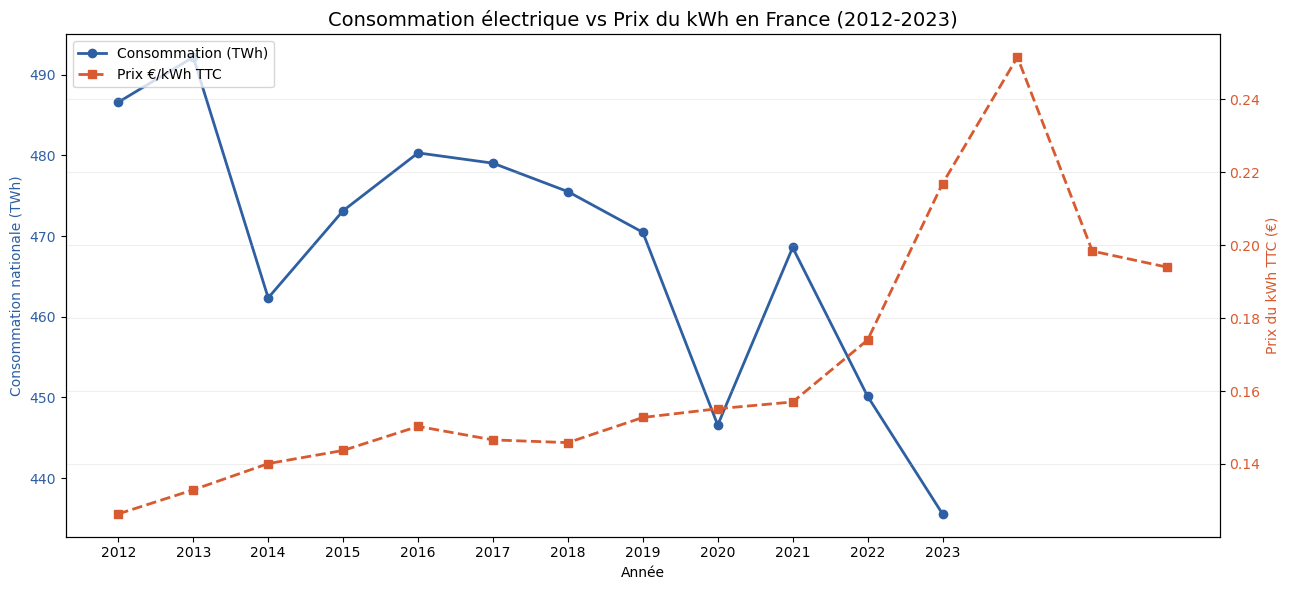

Consommation (TWh) vs Prix (€/kWh) :
       Consommation TWh  Prix €/kWh
Année                              
2012              487.0      0.1263
2013              492.0      0.1329
2014              462.0      0.1401
2015              473.0      0.1437
2016              480.0      0.1503
2017              479.0      0.1466
2018              476.0      0.1458
2019              470.0      0.1528
2020              447.0      0.1552
2021              469.0      0.1570
2022              450.0      0.1740
2023              436.0      0.2169
2024                NaN      0.2516
2025                NaN      0.1984
2026                NaN      0.1940


In [57]:
# Consommation annuelle en TWh (plus lisible que MW)
conso_twh = df[df['Année'] <= 2023].groupby('Année')['Consommation (kWh)'].sum() / 1e9

# Prix moyen par année
prix_par_annee = df_prix6.groupby('Année')['PART_VARIABLE_TTC'].mean()

fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche — consommation en TWh
ax1.plot(conso_twh.index, conso_twh.values,
         color='#2E5FA3', linewidth=2, marker='o', label='Consommation (TWh)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Consommation nationale (TWh)', color='#2E5FA3')
ax1.tick_params(axis='y', labelcolor='#2E5FA3')

# Axe droit — prix €/kWh
ax2 = ax1.twinx()
ax2.plot(prix_par_annee.index, prix_par_annee.values,
         color='#D85A30', linewidth=2, marker='s',
         linestyle='--', label='Prix €/kWh TTC')
ax2.set_ylabel('Prix du kWh TTC (€)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title("Consommation électrique vs Prix du kWh en France (2012-2023)", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('graphique4_conso_prix.png')
plt.show()

print("Consommation (TWh) vs Prix (€/kWh) :")
print(pd.DataFrame({'Consommation TWh': conso_twh.round(0), 
                    'Prix €/kWh': prix_par_annee.round(4)}))

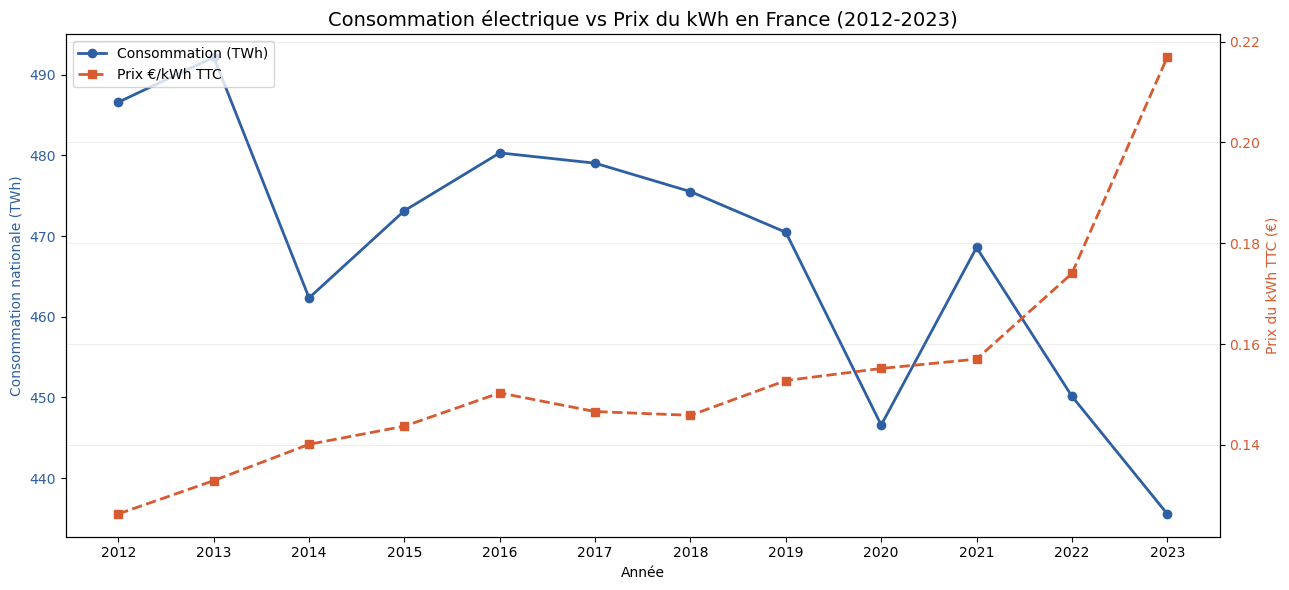

In [60]:
# Filtrer jusqu'à 2023 seulement
conso_twh_clean = conso_twh.loc[2012:2023]
prix_clean = prix_par_annee.loc[2012:2023]

fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche — consommation en TWh
ax1.plot(conso_twh_clean.index, conso_twh_clean.values,
         color='#2E5FA3', linewidth=2, marker='o', label='Consommation (TWh)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Consommation nationale (TWh)', color='#2E5FA3')
ax1.tick_params(axis='y', labelcolor='#2E5FA3')

# Axe droit — prix €/kWh
ax2 = ax1.twinx()
ax2.plot(prix_clean.index, prix_clean.values,
         color='#D85A30', linewidth=2, marker='s',
         linestyle='--', label='Prix €/kWh TTC')
ax2.set_ylabel('Prix du kWh TTC (€)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title("Consommation électrique vs Prix du kWh en France (2012-2023)", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('graphique4_conso_prix.png')
plt.show()

In [61]:
# Chiffres exacts de variation
prix_2012 = prix_clean[2012]
prix_2023 = prix_clean[2023]
conso_2012 = conso_twh_clean[2012]
conso_2023 = conso_twh_clean[2023]

variation_prix_total = ((prix_2023 - prix_2012) / prix_2012) * 100
variation_conso_total = ((conso_2023 - conso_2012) / conso_2012) * 100

# Variation 2021-2023 (période crise)
prix_2021 = prix_clean[2021]
conso_2021 = conso_twh_clean[2021]

variation_prix_crise = ((prix_2023 - prix_2021) / prix_2021) * 100
variation_conso_crise = ((conso_2023 - conso_2021) / conso_2021) * 100

print("=== PÉRIODE COMPLÈTE 2012-2023 ===")
print(f"Prix 2012 : {prix_2012:.4f} €/kWh")
print(f"Prix 2023 : {prix_2023:.4f} €/kWh")
print(f"Variation prix : +{variation_prix_total:.1f}%")
print()
print(f"Consommation 2012 : {conso_2012:.0f} TWh")
print(f"Consommation 2023 : {conso_2023:.0f} TWh")
print(f"Variation conso : {variation_conso_total:.1f}%")
print()
print("=== PÉRIODE CRISE 2021-2023 ===")
print(f"Prix 2021 : {prix_2021:.4f} €/kWh")
print(f"Prix 2023 : {prix_2023:.4f} €/kWh")
print(f"Variation prix : +{variation_prix_crise:.1f}%")
print()
print(f"Consommation 2021 : {conso_2021:.0f} TWh")
print(f"Consommation 2023 : {conso_2023:.0f} TWh")
print(f"Variation conso : {variation_conso_crise:.1f}%")

=== PÉRIODE COMPLÈTE 2012-2023 ===
Prix 2012 : 0.1263 €/kWh
Prix 2023 : 0.2169 €/kWh
Variation prix : +71.7%

Consommation 2012 : 487 TWh
Consommation 2023 : 436 TWh
Variation conso : -10.5%

=== PÉRIODE CRISE 2021-2023 ===
Prix 2021 : 0.1570 €/kWh
Prix 2023 : 0.2169 €/kWh
Variation prix : +38.2%

Consommation 2021 : 469 TWh
Consommation 2023 : 436 TWh
Variation conso : -7.0%


In [62]:
# Lire le fichier Excel
df_residentiel = pd.read_excel('consommation_energie_parc_residentiel_1990_2023_v2.xlsx', sheet_name=None)

# Voir tous les onglets disponibles
print(df_residentiel.keys())


dict_keys(['parc_residences', 'Conso_usage'])


In [63]:
# Voir tous les onglets du fichier
print(list(df_residentiel.keys()))

['parc_residences', 'Conso_usage']


In [64]:
# Charger l'onglet consommation par usage
df_conso_usage = df_residentiel['Conso_usage']

# Voir les 20 premières lignes
df_conso_usage.head(20)

,CONSOMMATION ENERGETIQUE DU SECTEUR RESIDENTIEL,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Les données de consommation diffusées ici sont...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Elle diffèrent légèrement des données du bilan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"À climat réel, en TWh PCI",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Usage,Energie,1990.000000,1991.000000,1992.000000,1993.000000,1994.000000,1995.000000,1996.000000,1997.000000,...,2014.000000,2015.000000,2016.000000,2017.000000,2018.000000,2019.000000,2020.000000,2021.000000,2022.000000,2023.000000
8,Chauffage,Electricité hors Pompe à chaleur,34.782231,41.486715,40.849617,40.420564,36.975272,37.077336,42.938031,38.154489,...,37.856193,42.349088,46.372674,42.913250,40.560210,40.248805,36.971922,42.877623,33.136236,32.767771
9,Chauffage,Electricité Pompe à chaleur,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.872226,4.657443,5.728366,6.231458,6.824979,7.368447,7.736055,10.827411,9.806370,10.764437


In [66]:
# Recharger avec les bons en-têtes (ligne 7)
df_elec_res = pd.read_excel('consommation_energie_parc_residentiel_1990_2023_v2.xlsx', 
                             sheet_name='Conso_usage', 
                             header=7)

# Explorer la structure
print("Shape :", df_elec_res.shape)
print("\nColonnes :", df_elec_res.columns.tolist())
print("\nValeurs manquantes :")
print(df_elec_res.isnull().sum())
print("\nDoublons :", df_elec_res.duplicated().sum())

Shape : (52, 36)

Colonnes : ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35']

Valeurs manquantes :
Unnamed: 0      4
Unnamed: 1     12
Unnamed: 2     15
Unnamed: 3     15
Unnamed: 4     15
Unnamed: 5     15
Unnamed: 6     15
Unnamed: 7     15
Unnamed: 8     15
Unnamed: 9     15
Unnamed: 10    15
Unnamed: 11    15
Unnamed: 12    15
Unnamed: 13    15
Unnamed: 14    15
Unnamed: 15    15
Unnamed: 16    15
Unnamed: 17    15
Unnamed: 18    15
Unnamed: 19    13
Unnamed: 20    13
Unnamed: 21    13
Unnamed: 22    12
Unna

In [68]:
# Voir les 12 premières lignes brutes pour trouver où commencent les données
df_brut = pd.read_excel('consommation_energie_parc_residentiel_1990_2023_v2.xlsx', sheet_name='Conso_usage', header=None)
df_brut.head(12)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,CONSOMMATION ENERGETIQUE DU SECTEUR RESIDENTIEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Les données de consommation diffusées ici sont...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Elle diffèrent légèrement des données du bilan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"À climat réel, en TWh PCI",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Usage,Energie,1990.000000,1991.000000,1992.000000,1993.000000,1994.000000,1995.000000,1996.000000,1997.000000,...,2014.000000,2015.000000,2016.000000,2017.000000,2018.000000,2019.000000,2020.000000,2021.000000,2022.000000,2023.000000
9,Chauffage,Electricité hors Pompe à chaleur,34.782231,41.486715,40.849617,40.420564,36.975272,37.077336,42.938031,38.154489,...,37.856193,42.349088,46.372674,42.913250,40.560210,40.248805,36.971922,42.877623,33.136236,32.767771


In [70]:
# Recharger avec header=8
df_elec_res = pd.read_excel('consommation_energie_parc_residentiel_1990_2023_v2.xlsx', 
                             sheet_name='Conso_usage', 
                             header=8)

# Vérifier
print(df_elec_res.shape)
print(df_elec_res.columns.tolist()[:5])
df_elec_res.head(5)

(51, 36)
['Usage', 'Energie', 1990, 1991, 1992]


,Usage,Energie,1990,1991,1992,1993,1994,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Chauffage,Electricité hors Pompe à chaleur,34.782231,41.486715,40.849617,40.420564,36.975272,37.077336,42.938031,38.154489,...,37.856193,42.349088,46.372674,42.913250,40.560210,40.248805,36.971922,42.877623,33.136236,32.767771
1,Chauffage,Electricité Pompe à chaleur,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.872226,4.657443,5.728366,6.231458,6.824979,7.368447,7.736055,10.827411,9.806370,10.764437
2,Chauffage,Gaz naturel,100.300595,121.594641,118.041635,124.761603,115.415008,122.678615,140.392705,125.375147,...,102.261555,113.776185,123.691710,117.737948,112.240377,109.163955,104.307961,112.452208,88.138697,79.188176
3,Chauffage,Fioul domestique,97.814843,105.802586,100.482446,93.675179,83.386566,83.936425,90.979010,82.982482,...,47.239472,49.102129,51.913884,49.385116,45.074303,43.479451,39.599210,42.353813,30.190208,27.080257
4,Chauffage,Gaz de pétrole liquéfié,5.475369,6.803695,6.998386,6.908792,6.414242,6.888578,8.036117,7.468422,...,3.233468,3.692235,4.123809,4.121800,4.111602,4.155831,3.948104,4.208551,3.302231,3.183924


In [71]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes :")
print(df_elec_res.isnull().sum())
print("\nDoublons :", df_elec_res.duplicated().sum())
print("\nToutes les énergies disponibles :")
print(df_elec_res['Energie'].unique())

Valeurs manquantes :
Usage       4
Energie    12
1990       15
1991       15
1992       15
1993       15
1994       15
1995       15
1996       15
1997       15
1998       15
1999       15
2000       15
2001       15
2002       15
2003       15
2004       15
2005       15
2006       15
2007       13
2008       13
2009       13
2010       12
2011       13
2012       13
2013       13
2014       13
2015       13
2016       13
2017       13
2018       13
2019       13
2020       13
2021       13
2022       13
2023       13
dtype: int64

Doublons : 3

Toutes les énergies disponibles :
['Electricité hors Pompe à chaleur' 'Electricité Pompe à chaleur'
 'Gaz naturel' 'Fioul domestique' 'Gaz de pétrole liquéfié' 'Chaleur'
 'Autres énergies' 'Bois' 'ENR Pompe à chaleur' 'Solaire' 'Electricité '
 'Electricité' 'Toutes Energies' nan]


In [72]:
# Garder seulement la ligne 'Electricité' total général
df_elec_total = df_elec_res[df_elec_res['Energie'] == 'Electricité']

# Vérifier
print(df_elec_total[['Usage', 'Energie']])

# Pivoter pour avoir les années en index
annees = [col for col in df_elec_res.columns if isinstance(col, int) and 2012 <= col <= 2023]
elec_residentielle = df_elec_total[annees].sum()
elec_residentielle.index = elec_residentielle.index.astype(int)

print("\nConsommation électrique résidentielle par année (TWh) :")
print(elec_residentielle.round(1))

            Usage      Energie
22     Spécifique  Electricité
23  Climatisation  Electricité

Consommation électrique résidentielle par année (TWh) :
2012    81.3
2013    82.9
2014    79.7
2015    79.6
2016    79.9
2017    79.0
2018    78.6
2019    77.9
2020    81.2
2021    81.2
2022    78.6
2023    75.2
dtype: float64


In [73]:
# Garder TOUTES les lignes contenant 'Electricité'
df_elec_all = df_elec_res[df_elec_res['Energie'].str.contains('Electr', na=False)]

print("Lignes sélectionnées :")
print(df_elec_all[['Usage', 'Energie']].to_string())

# Additionner toutes les lignes électricité par année
annees = [col for col in df_elec_res.columns if isinstance(col, int) and 2012 <= col <= 2023]
elec_residentielle = df_elec_all[annees].sum()
elec_residentielle.index = elec_residentielle.index.astype(int)

print("\nConsommation électrique résidentielle TOTALE par année (TWh) :")
print(elec_residentielle.round(1))

Lignes sélectionnées :
            Usage                           Energie
0       Chauffage  Electricité hors Pompe à chaleur
1       Chauffage       Electricité Pompe à chaleur
9             ECS  Electricité hors Pompe à chaleur
10            ECS       Electricité Pompe à chaleur
19        Cuisson                      Electricité 
22     Spécifique                       Electricité
23  Climatisation                       Electricité
24    Tous usages  Electricité hors Pompe à chaleur
25    Tous usages       Electricité Pompe à chaleur

Consommation électrique résidentielle TOTALE par année (TWh) :
2012    333.2
2013    345.2
2014    308.3
2015    318.0
2016    327.4
2017    318.8
2018    314.5
2019    313.5
2020    316.8
2021    333.3
2022    305.2
2023    296.0
dtype: float64


In [74]:
# Exclure les lignes 'Tous usages' qui sont des totaux
df_elec_clean = df_elec_all[df_elec_all['Usage'] != 'Tous usages']

print("Lignes sélectionnées :")
print(df_elec_clean[['Usage', 'Energie']].to_string())

# Additionner
elec_residentielle = df_elec_clean[annees].sum()
elec_residentielle.index = elec_residentielle.index.astype(int)

print("\nConsommation électrique résidentielle TOTALE par année (TWh) :")
print(elec_residentielle.round(1))

Lignes sélectionnées :
            Usage                           Energie
0       Chauffage  Electricité hors Pompe à chaleur
1       Chauffage       Electricité Pompe à chaleur
9             ECS  Electricité hors Pompe à chaleur
10            ECS       Electricité Pompe à chaleur
19        Cuisson                      Electricité 
22     Spécifique                       Electricité
23  Climatisation                       Electricité

Consommation électrique résidentielle TOTALE par année (TWh) :
2012    166.6
2013    172.6
2014    154.2
2015    159.0
2016    163.7
2017    159.4
2018    157.3
2019    156.7
2020    158.4
2021    166.7
2022    152.6
2023    148.0
dtype: float64


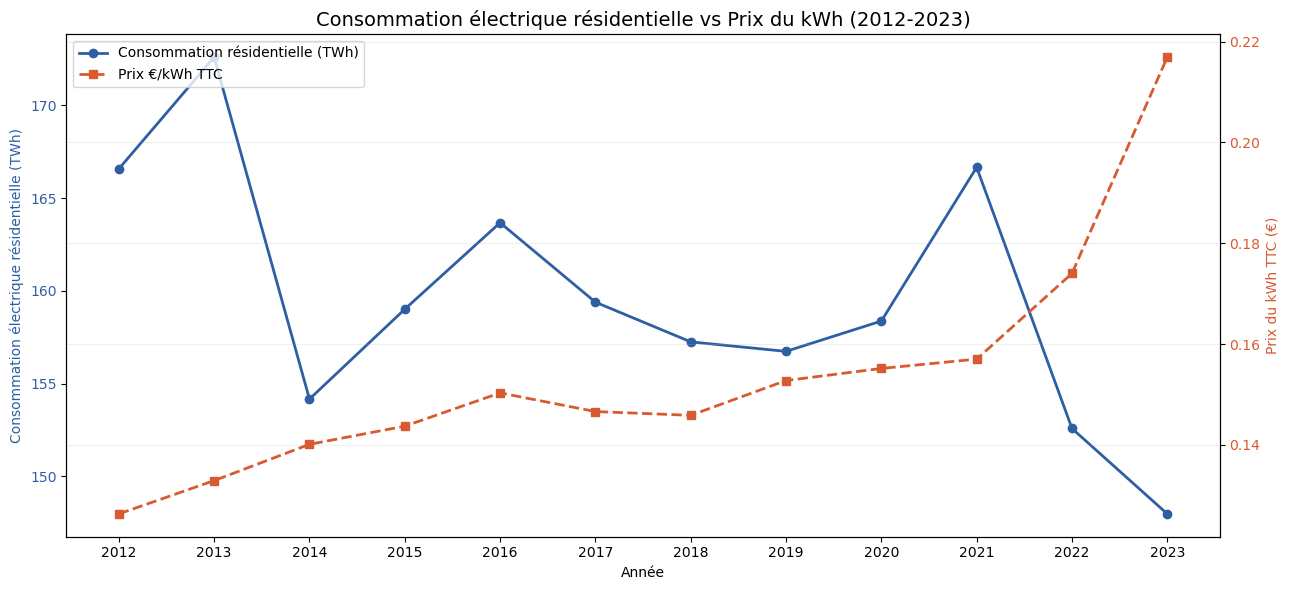

Prix 2012 : 0.1263 €/kWh → Prix 2023 : 0.2169 €/kWh
Variation prix : +71.7%
Consommation 2012 : 166.6 TWh → 2023 : 148.0 TWh
Variation consommation : -11.2%


In [75]:
# Graphique consommation résidentielle vs prix
fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche — consommation résidentielle en TWh
ax1.plot(elec_residentielle.index, elec_residentielle.values,
         color='#2E5FA3', linewidth=2, marker='o', label='Consommation résidentielle (TWh)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Consommation électrique résidentielle (TWh)', color='#2E5FA3')
ax1.tick_params(axis='y', labelcolor='#2E5FA3')

# Axe droit — prix €/kWh
ax2 = ax1.twinx()
ax2.plot(prix_clean.index, prix_clean.values,
         color='#D85A30', linewidth=2, marker='s',
         linestyle='--', label='Prix €/kWh TTC')
ax2.set_ylabel('Prix du kWh TTC (€)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title("Consommation électrique résidentielle vs Prix du kWh (2012-2023)", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('graphique4_conso_residentielle_prix.png')
plt.show()

# Chiffres exacts
prix_2012 = prix_clean[2012]
prix_2023 = prix_clean[2023]
conso_2012 = elec_residentielle[2012]
conso_2023 = elec_residentielle[2023]

variation_prix = ((prix_2023 - prix_2012) / prix_2012) * 100
variation_conso = ((conso_2023 - conso_2012) / conso_2012) * 100

print(f"Prix 2012 : {prix_2012:.4f} €/kWh → Prix 2023 : {prix_2023:.4f} €/kWh")
print(f"Variation prix : +{variation_prix:.1f}%")
print(f"Consommation 2012 : {conso_2012:.1f} TWh → 2023 : {conso_2023:.1f} TWh")
print(f"Variation consommation : {variation_conso:.1f}%")

In [76]:
# Chiffres exacts avec consommation résidentielle
prix_2012 = prix_clean[2012]
prix_2021 = prix_clean[2021]
prix_2023 = prix_clean[2023]

conso_2012 = elec_residentielle[2012]
conso_2021 = elec_residentielle[2021]
conso_2023 = elec_residentielle[2023]

variation_prix_total = ((prix_2023 - prix_2012) / prix_2012) * 100
variation_conso_total = ((conso_2023 - conso_2012) / conso_2012) * 100

variation_prix_crise = ((prix_2023 - prix_2021) / prix_2021) * 100
variation_conso_crise = ((conso_2023 - conso_2021) / conso_2021) * 100

print("=== PÉRIODE COMPLÈTE 2012-2023 ===")
print(f"Prix 2012 : {prix_2012:.4f} €/kWh")
print(f"Prix 2023 : {prix_2023:.4f} €/kWh")
print(f"Variation prix : +{variation_prix_total:.1f}%")
print()
print(f"Consommation résidentielle 2012 : {conso_2012:.1f} TWh")
print(f"Consommation résidentielle 2023 : {conso_2023:.1f} TWh")
print(f"Variation consommation : {variation_conso_total:.1f}%")
print()
print("=== PÉRIODE CRISE 2021-2023 ===")
print(f"Prix 2021 : {prix_2021:.4f} €/kWh")
print(f"Prix 2023 : {prix_2023:.4f} €/kWh")
print(f"Variation prix : +{variation_prix_crise:.1f}%")
print()
print(f"Consommation résidentielle 2021 : {conso_2021:.1f} TWh")
print(f"Consommation résidentielle 2023 : {conso_2023:.1f} TWh")
print(f"Variation consommation : {variation_conso_crise:.1f}%")

=== PÉRIODE COMPLÈTE 2012-2023 ===
Prix 2012 : 0.1263 €/kWh
Prix 2023 : 0.2169 €/kWh
Variation prix : +71.7%

Consommation résidentielle 2012 : 166.6 TWh
Consommation résidentielle 2023 : 148.0 TWh
Variation consommation : -11.2%

=== PÉRIODE CRISE 2021-2023 ===
Prix 2021 : 0.1570 €/kWh
Prix 2023 : 0.2169 €/kWh
Variation prix : +38.2%

Consommation résidentielle 2021 : 166.7 TWh
Consommation résidentielle 2023 : 148.0 TWh
Variation consommation : -11.2%


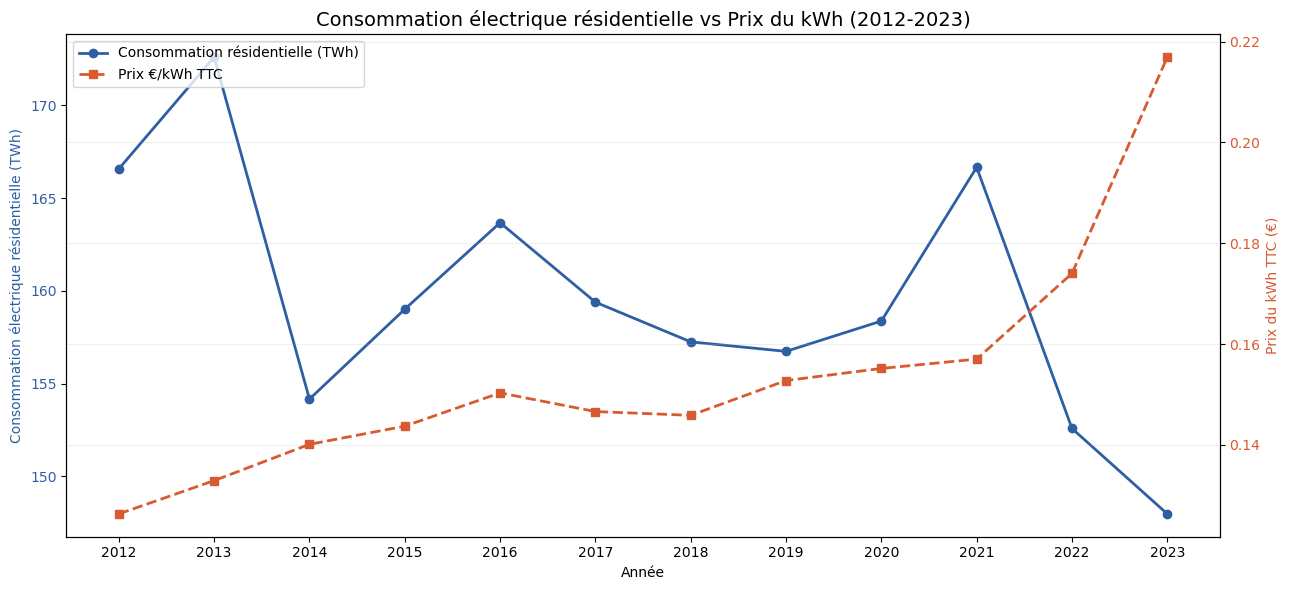

In [77]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche — consommation résidentielle en TWh
ax1.plot(elec_residentielle.index, elec_residentielle.values,
         color='#2E5FA3', linewidth=2, marker='o', 
         label='Consommation résidentielle (TWh)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Consommation électrique résidentielle (TWh)', color='#2E5FA3')
ax1.tick_params(axis='y', labelcolor='#2E5FA3')

# Axe droit — prix €/kWh
ax2 = ax1.twinx()
ax2.plot(prix_clean.index, prix_clean.values,
         color='#D85A30', linewidth=2, marker='s',
         linestyle='--', label='Prix €/kWh TTC')
ax2.set_ylabel('Prix du kWh TTC (€)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title("Consommation électrique résidentielle vs Prix du kWh (2012-2023)", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(range(2012, 2024))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('graphique4_conso_residentielle_prix.png')
plt.show()